In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
from scipy.stats import norm

colonne = pd.read_csv("a2142.dat")

z_obs = colonne["z"].values

z_min = np.min(z_obs)
z_max = np.max(z_obs)

In [3]:
def log_prior(theta):
    z0, sigma_z, f = theta
    if 0.0 < z0 < 1.0 and 0.0 < sigma_z < 1.0 and 0.0 < f < 1.0:
        return 0.0 
    return -np.inf

def log_likelihood(theta, z_obs):
    z0, sigma_z, f = theta
    uniforme = 1.0/(z_max - z_min)
    model = f * norm.pdf(z_obs, loc=z0, scale=sigma_z) + (1 - f) * uniforme
    return np.sum(np.log(model))

def log_posterior(theta, z_obs):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, z_obs)

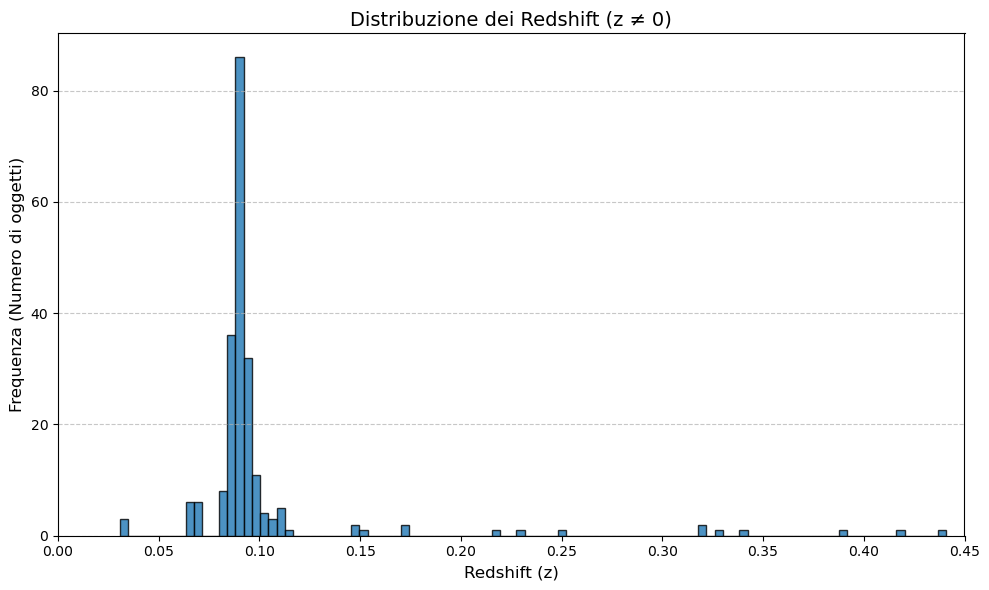

In [4]:
plt.figure(figsize=(10, 6))

# bins=50 divide i dati in 50 colonne. Puoi aumentare questo numero 
# se vuoi vedere una distribuzione più "fine"
plt.hist(z_obs, bins=100, color='#1f77b4', edgecolor='black', alpha=0.8)

# 4. Personalizza l'estetica del grafico
plt.title('Distribuzione dei Redshift (z ≠ 0)', fontsize=14)
plt.xlabel('Redshift (z)', fontsize=12)
plt.xlim(0, 0.45)  # Aggiungiamo un piccolo margine ai limiti
plt.ylabel('Frequenza (Numero di oggetti)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 5. Visualizza il grafico a schermo 
# (Se vuoi salvarlo come immagine, usa plt.savefig('nome_file.png') al posto di show)
plt.show()

Inizializzazione dei camminatori MCMC...
Lancio MCMC con 10000 step per 32 camminatori...


100%|██████████| 10000/10000 [00:18<00:00, 533.08it/s]


Campionamento completato.


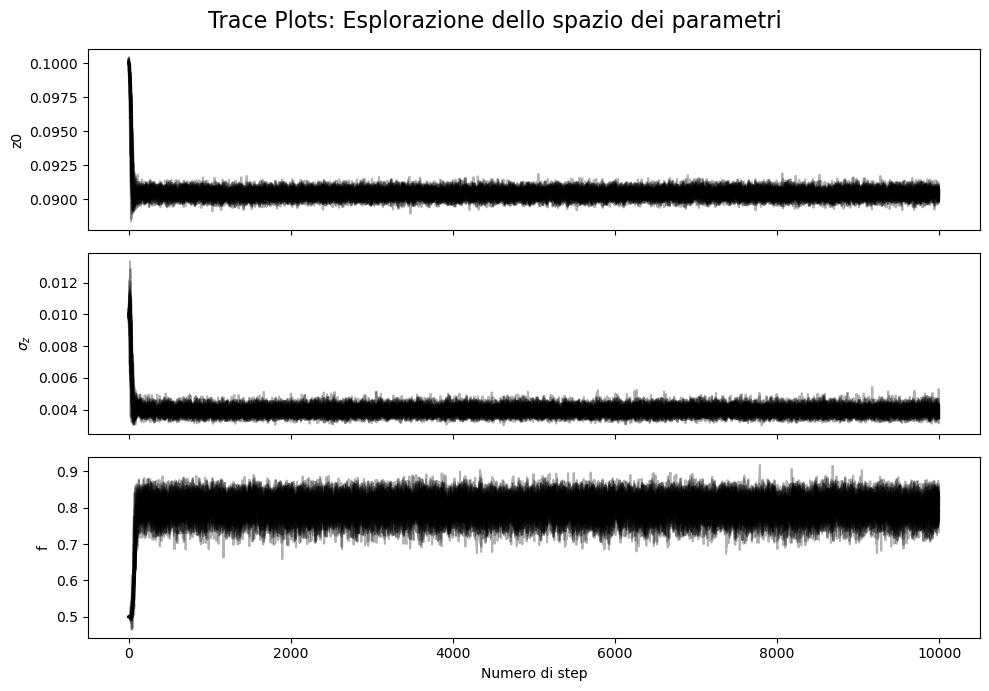

In [5]:
print("Inizializzazione dei camminatori MCMC...")

n_dim = 3         # Numero di parametri (H_0, Omega_m)
n_walkers = 32    # Numero di camminatori
n_steps = 10000    # Passi per ogni camminatore

stima_iniziale = [0.1, 0.01, 0.5]  # [z0_guess, sigma_z_guess, f_guess]
#attenzine, scegliere condizioni iniziali sbagliate porta i camminatori a perdersi

pos_iniziali = stima_iniziale + 1e-4 * np.random.randn(n_walkers, n_dim)


#lancio emcee
print(f"Lancio MCMC con {n_steps} step per {n_walkers} camminatori...")
sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_posterior, args=(z_obs,))

#barra di caricamento
sampler.run_mcmc(pos_iniziali, n_steps, progress=True)
print("Campionamento completato.")

samples_walkers = sampler.get_chain()
nomi_params = ["z0", r"$\sigma_z$", "f"]

fig, axes = plt.subplots(n_dim, 1, figsize=(10, 7), sharex=True)

for i in range(n_dim):
    ax = axes[i]
    # Plottiamo le traiettorie di tutti i camminatori per il parametro i-esimo
    ax.plot(samples_walkers[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(nomi_params[i])
    
axes[-1].set_xlabel("Numero di step")
plt.suptitle("Trace Plots: Esplorazione dello spazio dei parametri", fontsize=16)
plt.tight_layout()
plt.show()

Estrazione dei campioni e rimozione del burn-in...
Campioni validi estratti: 304000


### Risultati dell'Inferenza (Mediana e $1\sigma$):

**$z_0$**: $ 0.09_{-0.00}^{+0.00} $

**$\sigma_z$**: $ 0.004_{-0.000}^{+0.001} $

**$f$**: $ 0.80_{-0.06}^{+0.05} $


Generazione del Corner Plot...


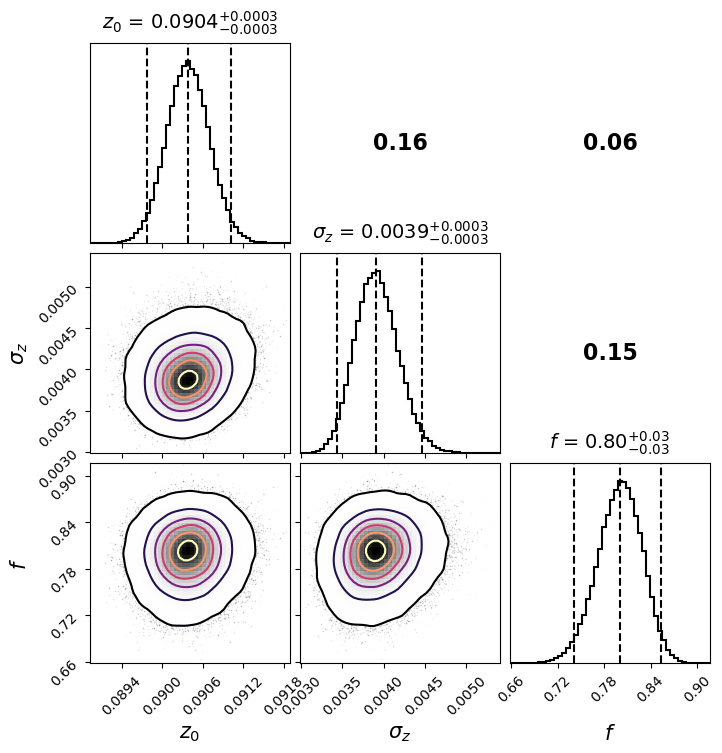

In [30]:
import corner
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Estrazione dei campioni e rimozione del burn-in...")

# Togliamo i primi 500 step (burn-in).
burn_in = 500
samples_analisis = sampler.get_chain(discard=burn_in, flat=True)

nomi_params = [r"$z_0$", r"$\sigma_z$", r"$f$"]
n_dim = len(nomi_params)
samples_df = pd.DataFrame(samples_analisis, columns=nomi_params)

print(f"Campioni validi estratti: {len(samples_df)}")

# === STAMPA DEI RISULTATI NUMERICI ===
risultati = []
for i, col in enumerate(nomi_params):
    q16, q50, q84 = np.percentile(samples_df[col], [2.5, 50, 97.5])
    err_minus = q50 - q16
    err_plus = q84 - q50
    prec = ".3f" if col == r"$\sigma_z$" else ".2f"
    risultati.append(f"**{col}**: $ {q50:{prec}}_{{-{err_minus:{prec}}}}^{{+{err_plus:{prec}}}} $")

display(Markdown("### Risultati dell'Inferenza (Mediana e $1\sigma$):"))
for res in risultati:
    display(Markdown(res))

print("\nGenerazione del Corner Plot...")

corr_matrix = samples_df.corr(method='pearson').values

# ECCO LA MODIFICA: Più valori = più curve nel grafico 2D. 
# Ho inserito 6 livelli che racchiudono il 10%, 30%, 50%, 68.3%, 86.4% e 98.8% dei dati.
livelli_2d = [0.10, 0.30, 0.50, 0.683, 0.864, 0.988]

# Generazione del plot
fig = corner.corner(
    samples_analisis,
    labels=nomi_params,
    bins=50,
    quantiles=[0.025, 0.5, 0.975], 
    show_titles=False, # <-- MODIFICA: Disabilita i titoli automatici di corner
    label_kwargs={"fontsize": 15},
    
    color="black", 
    fill_contours=False,
    contour_kwargs={"cmap": "magma", "colors": None, "linewidths": 1.5},
    
    plot_datapoints=True,
    data_kwargs={"alpha": 0.1, "color": "gray", "ms": 1.0},
    
    hist_kwargs={"linewidth": 1.5, "histtype": "step"},
    smooth=1.2,
    levels=livelli_2d
)

axes = np.array(fig.axes).reshape((n_dim, n_dim))

# === AGGIUNTA DEI TITOLI PERSONALIZZATI SULLA DIAGONALE ===
for i, col in enumerate(nomi_params):
    ax = axes[i, i] # Prende il grafico 1D sulla diagonale
    
    # Ricalcoliamo i quantili per il titolo
    q16, q50, q84 = np.percentile(samples_df[col], [16, 50, 84])
    err_minus = q50 - q16
    err_plus = q84 - q50
    
    # Scegliamo la precisione: 3 per sigma_z, 2 per gli altri
    if col == r"$\sigma_z$": prec = ".4f" 
    if col == r"$z_0$": prec = ".4f" 
    if col == r"$f$": prec = ".2f"
    
    # Creiamo la stringa in formato LaTeX per il titolo
    titolo = f"{col} = ${q50:{prec}}_{{-{err_minus:{prec}}}}^{{+{err_plus:{prec}}}}$"
    ax.set_title(titolo, fontsize=14, pad=10)

# === AGGIUNTA DEI COEFFICIENTI DI PEARSON NEL TRIANGOLO SUPERIORE ===
for i in range(n_dim):
    for j in range(n_dim):
        ax = axes[i, j]
        
        if j > i:
            ax.set_visible(True)
            ax.set_frame_on(False) 
            ax.set_xticks([])      
            ax.set_yticks([])      
            
            corr_val = corr_matrix[i, j]
            
            ax.text(0.5, 0.5, f"{corr_val:.2f}",
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=16,
                    fontweight='bold',
                    transform=ax.transAxes)

plt.show()

z0_mcmc, sigma_z_mcmc, f_mcmc = np.percentile(samples_analisis, 50, axis=0)

In [16]:
prob_cluster = f_mcmc * norm.pdf(z_obs, loc=z0_mcmc, scale=sigma_z_mcmc)
prob_fondo = (1 - f_mcmc) * (1.0/(z_max - z_min))
prob_totale = prob_cluster + prob_fondo

rapporto = prob_cluster / prob_totale

colonne["p_cluster"] = rapporto

soglia = 3*sigma_z_mcmc
colonne["membro_cluster"] = np.abs(z_obs - z0_mcmc) <= soglia
df_cluster = colonne[colonne["membro_cluster"]].copy()

galassie_totali = len(colonne)
galassie_ammasso = len(df_cluster)
galassie_scartate = galassie_totali - galassie_ammasso

print(f"--- FILTRAGGIO COMPLETATO ---")
print(f"Galassie totali iniziali : {galassie_totali}")
print(f"Galassie dell'ammasso    : {galassie_ammasso}")
print(f"Galassie di background scartate: {galassie_scartate}")

percentili_z0 = np.percentile(samples_analisis[:, 0], [16, 50, 84])
percentili_sigma_z = np.percentile(samples_analisis[:, 1], [16, 50, 84])
err_z0= percentili_z0[2]-percentili_z0[1]
err_sigma_z = percentili_sigma_z[2] - percentili_sigma_z[1]

--- FILTRAGGIO COMPLETATO ---
Galassie totali iniziali : 216
Galassie dell'ammasso    : 174
Galassie di background scartate: 42


In [27]:
H0=70.0  # km/s/Mpc
c = 299792.458  # km/s
Distance = c * z0_mcmc / H0
err_dist = c * err_z0 / H0 

print(f"Stima della distanza: {Distance:.2f} Mpc +/- {err_dist:.2f} Mpc")
    
sigma_v = c * sigma_z_mcmc/(1+z0_mcmc)
err_disp = np.sqrt((c/(1+z0_mcmc) * err_sigma_z)**2 + (c*sigma_z_mcmc/(1+z0_mcmc)**2 * err_z0)**2)
print(f"Stima della dispersione in velocità: {sigma_v:.2f} +/- {err_disp:.2f} km/s")

raggio_cluster = Distance * np.tan(np.radians(10/60))  # Convertiamo 10 arcmin in gradi e poi in radianti
sigma_raggio_cluster = 100  # Assumiamo un'incertezza di 100 kpc sul raggio del cluster
print(f"Stima del raggio del cluster: {raggio_cluster:.2f} Mpc")

def massa_isoterma(sigma_v, r):
    G = 4.30091e-6  # kpc (km/s)^2 / M_sun
    return (2*sigma_v**2 * r * 1e3) / G

def massa_viriale(sigma_v, r_vir):
    G = 4.30091e-6  # kpc (km/s)^2 / M_sun
    return (3 * sigma_v**2 * r_vir) / G

G = 4.30091e-6  # kpc (km/s)^2 / M_sun
r_vir = 2 * 1e3  # Convertiamo Mpc in kpc
sigma_r_vir = 100  # Assumiamo un'incertezza di 100 kpc sul raggio viriale

err_massa_vir = np.sqrt((6 * sigma_v * err_disp * r_vir / G)**2 + (3 * sigma_v**2 * sigma_r_vir / G)**2)

err_massa_isoterma = np.sqrt((4 * sigma_v * err_disp * raggio_cluster * 1e3 / G)**2 + (2 * sigma_v**2 * sigma_raggio_cluster  / G)**2)

print(f"Stima della massa isoterma: {massa_isoterma(sigma_v, raggio_cluster):.2e} +/- {err_massa_isoterma:.2e} M_sun")
print(f"Stima della massa viriale: {massa_viriale(sigma_v, r_vir):.2e} +/- {err_massa_vir:.2e} M_sun")


massa_galassia = df_cluster["lgm_tot_p50"].values
err16 = df_cluster["lgm_tot_p16"].values
err84 = df_cluster["lgm_tot_p84"].values
errors= (err84 - err16)/2
err_somma_masse = 0
somma_masse = np.sum(10**(massa_galassia))  

rapporto_masse = somma_masse/massa_viriale(sigma_v, r_vir)
err_rapporto_masse = rapporto_masse * np.sqrt((err_somma_masse/somma_masse)**2 + (err_massa_vir/massa_viriale(sigma_v, r_vir))**2)
print(f"Stima della massa totale delle galassie nell'ammasso: {somma_masse:.2e} +/- {err_somma_masse:.2e} M_sun")
print(f"Rapporto massa totale galassie / massa viriale: {rapporto_masse:.2e} +/- {err_rapporto_masse:.2e}")
print(f"percentuale massa visibile: {100*rapporto_masse:.2f} +/- {100*err_rapporto_masse:.2f}%")
print("i telescopi hanno un limite alla magnitudine quindi non vediamo tutte le galassie, la stima della massa totale delle galassie è sottostimata, quindi abbiamo una stima della percentuale di massa invisibile inferiore alle aspettative (90%DM, 6/7perc gas), alcune galassie non rientrano")



Stima della distanza: 387.09 Mpc +/- 1.35 Mpc
Stima della dispersione in velocità: 1074.96 +/- 74.25 km/s
Stima del raggio del cluster: 1.13 Mpc
Stima della massa isoterma: 6.05e+14 +/- 9.94e+13 M_sun
Stima della massa viriale: 1.61e+15 +/- 2.37e+14 M_sun
Stima della massa totale delle galassie nell'ammasso: 1.17e+13 +/- 0.00e+00 M_sun
Rapporto massa totale galassie / massa viriale: 7.27e-03 +/- 1.07e-03
percentuale massa visibile: 0.73 +/- 0.11%
i telescopi hanno un limite alla magnitudine quindi non vediamo tutte le galassie, la stima della massa totale delle galassie è sottostimata, quindi abbiamo una stima della percentuale di massa invisibile inferiore alle aspettative (90%DM, 6/7perc gas), alcune galassie non rientrano


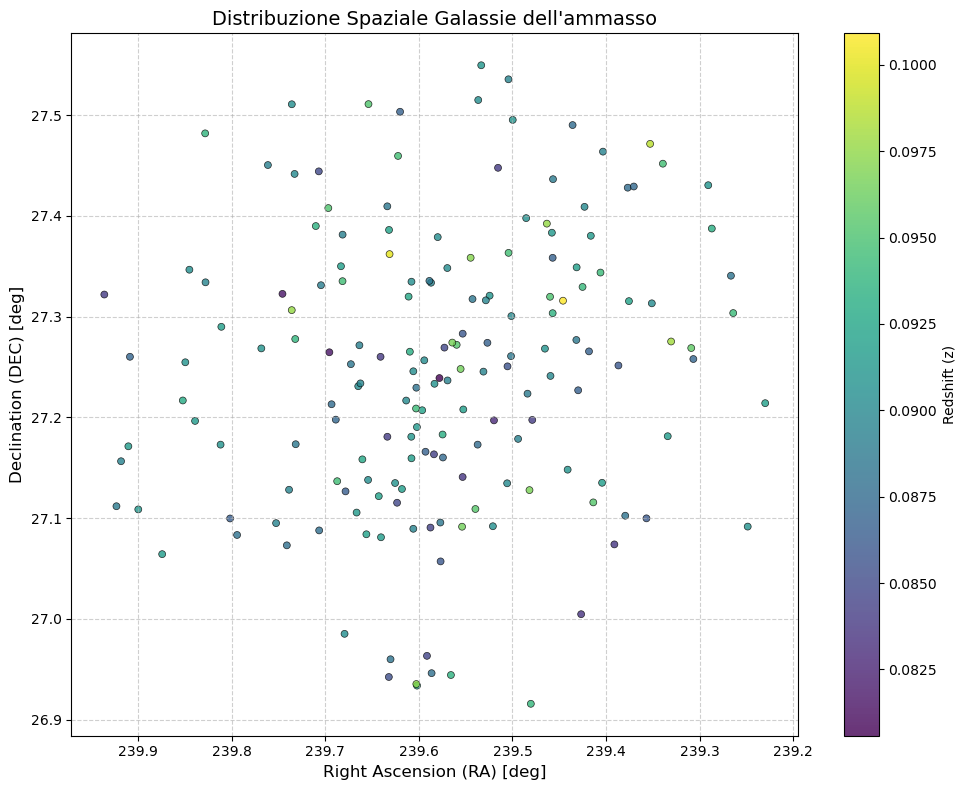

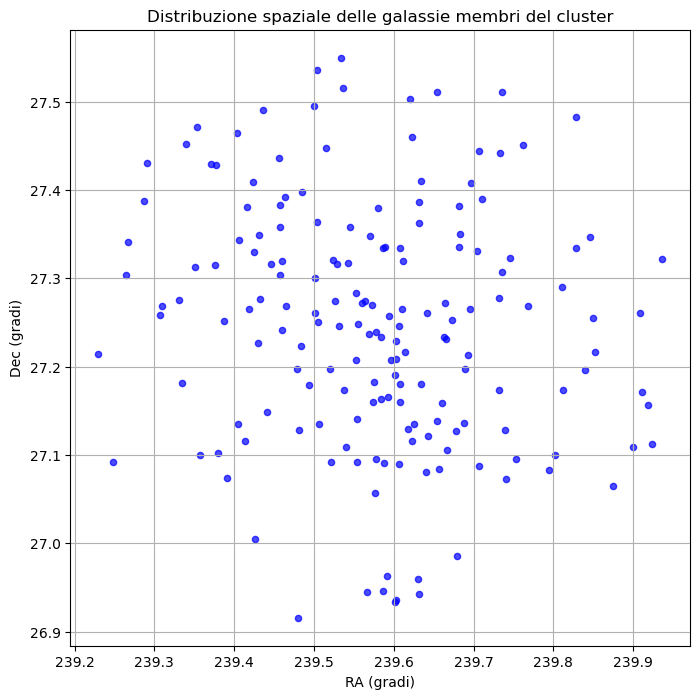

In [16]:
ra = df_cluster["ra"].values
dec = df_cluster["dec"].values
z_vals = df_cluster["z"].values

# 4. Creiamo il grafico a dispersione (scatter plot)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(ra, dec, s=25, c=z_vals, cmap='viridis', alpha=0.8, edgecolor='k', linewidth=0.5)

# 5. Aggiungiamo barra dei colori e dettagli
plt.colorbar(scatter, label='Redshift (z)')
plt.xlabel('Right Ascension (RA) [deg]', fontsize=12)
plt.ylabel('Declination (DEC) [deg]', fontsize=12)
plt.title('Distribuzione Spaziale Galassie dell\'ammasso', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

plt.gca().invert_xaxis()
plt.tight_layout()

# 7. Mostriamo il grafico
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(ra, dec, s=20, color="blue", alpha=0.7)
plt.xlabel("RA (gradi)")
plt.ylabel("Dec (gradi)")
plt.title("Distribuzione spaziale delle galassie membri del cluster")
plt.grid(True)
plt.show()